In [1]:
import matplotlib
matplotlib.rcParams['font.family'] = 'AR PL UKai CN'

In [2]:
# 输入父目录路径
root_dir = "/icislab/volume1/liuxiaolong/mmdetection/log"

In [3]:
import os
import json

# 遍历root_dir下所有A/B层级，读取scalars.json，记录A/B层级名
all_data = []
for ab_name in os.listdir(root_dir):
    ab_path = os.path.join(root_dir, ab_name)
    if not os.path.isdir(ab_path):
        continue
    # 只处理A/B层级
    for xxx in os.listdir(ab_path):
        xxx_path = os.path.join(ab_path, xxx)
        vis_data_path = os.path.join(xxx_path, 'vis_data')
        scalars_path = os.path.join(vis_data_path, 'scalars.json')
        if os.path.isfile(scalars_path):
            with open(scalars_path, 'r') as f:
                for line in f:
                    line = line.strip()
                    if line:
                        d = json.loads(line)
                        d['group'] = ab_name
                        all_data.append(d)
print(f'共读取{len(all_data)}条记录，分属{len(set(d["group"] for d in all_data))}组')

共读取248条记录，分属8组


In [4]:
import pandas as pd
from collections import defaultdict

# 按group和step合并，优先保留后出现的同step数据
group_step_dict = defaultdict(dict)
for d in all_data:
    group = d['group']
    step = d.get('step', None)
    if step is not None:
        group_step_dict[(group, step)].update(d)
df = pd.DataFrame(list(group_step_dict.values()))
df = df.sort_values(['group', 'step']).reset_index(drop=True)
df.head()

,base_lr,lr,data_time,loss,loss_cls,loss_bbox,time,epoch,iter,memory,...,d3.dn_loss_cls,d3.dn_loss_bbox,d3.dn_loss_iou,d4.dn_loss_cls,d4.dn_loss_bbox,d4.dn_loss_iou,loss_rpn_cls,loss_rpn_bbox,acc,loss_bbox_rf
0,NaN,NaN,0.108708,NaN,NaN,NaN,0.171801,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,0.083827,NaN,NaN,NaN,0.142704,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,0.083337,NaN,NaN,NaN,0.137171,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,0.081684,NaN,NaN,NaN,0.136063,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,0.087546,NaN,NaN,NaN,0.141634,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


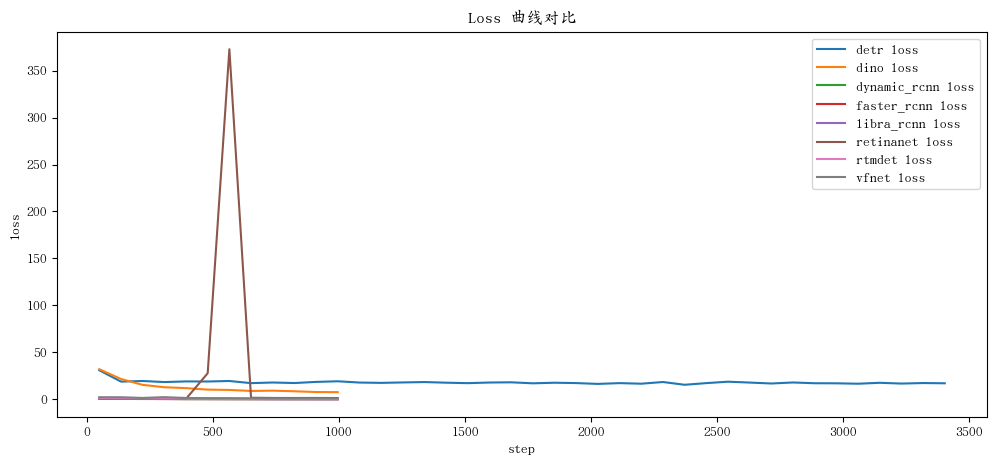

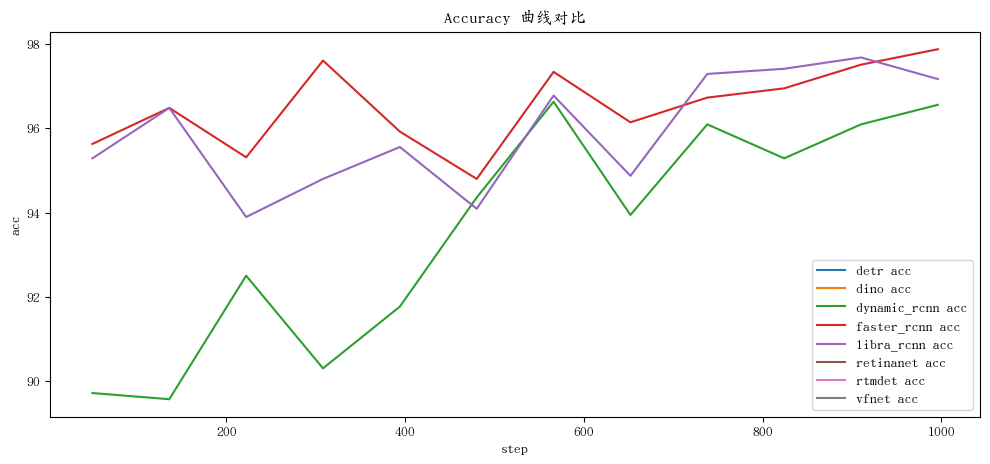

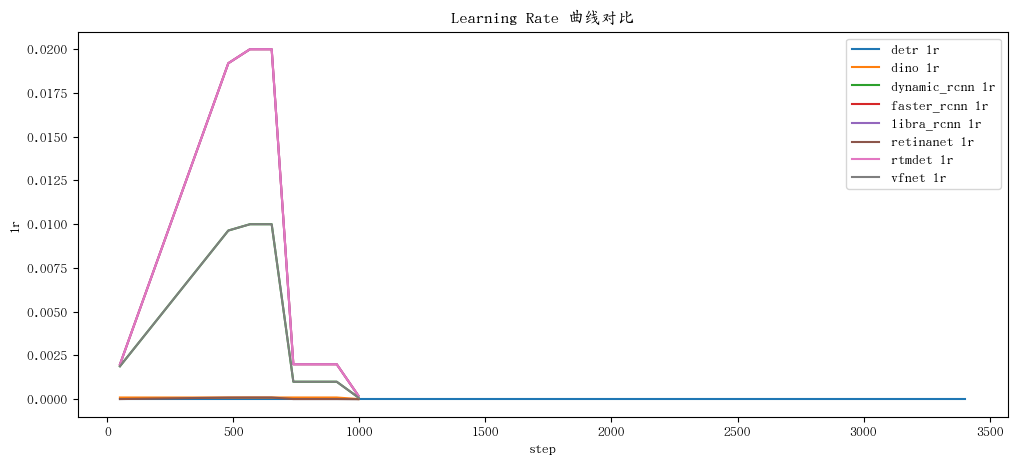

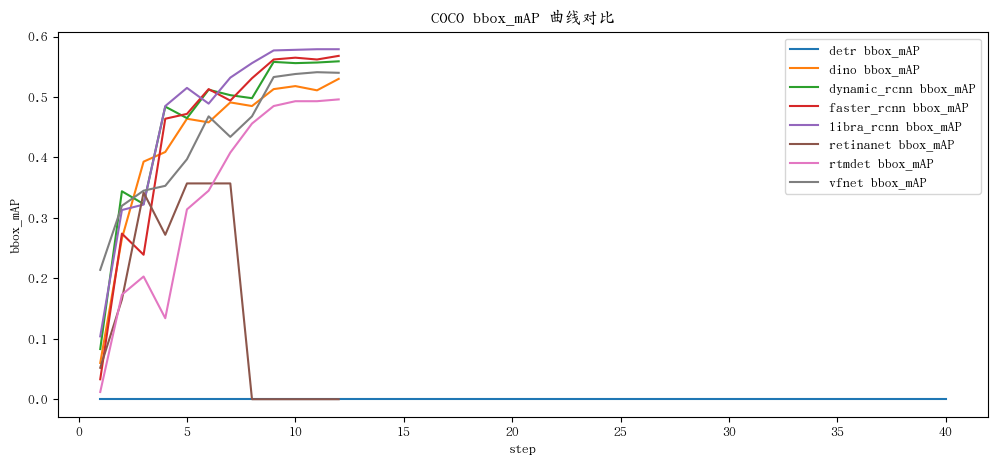

In [5]:
import matplotlib.pyplot as plt

# loss对比
plt.figure(figsize=(12, 5))
for group, dfg in df.groupby('group'):
    if 'loss' in dfg.columns:
        plt.plot(dfg['step'], dfg['loss'], label=f'{group} loss')
plt.xlabel('step')
plt.ylabel('loss')
plt.title('Loss 曲线对比')
plt.legend()
plt.show()

# acc对比
plt.figure(figsize=(12, 5))
for group, dfg in df.groupby('group'):
    if 'acc' in dfg.columns:
        plt.plot(dfg['step'], dfg['acc'], label=f'{group} acc')
plt.xlabel('step')
plt.ylabel('acc')
plt.title('Accuracy 曲线对比')
plt.legend()
plt.show()

# lr对比
plt.figure(figsize=(12, 5))
for group, dfg in df.groupby('group'):
    if 'lr' in dfg.columns:
        plt.plot(dfg['step'], dfg['lr'], label=f'{group} lr')
plt.xlabel('step')
plt.ylabel('lr')
plt.title('Learning Rate 曲线对比')
plt.legend()
plt.show()

# bbox_mAP对比
if 'coco/bbox_mAP' in df.columns:
    plt.figure(figsize=(12, 5))
    for group, dfg in df.groupby('group'):
        plt.plot(dfg['step'], dfg['coco/bbox_mAP'], label=f'{group} bbox_mAP')
    plt.xlabel('step')
    plt.ylabel('bbox_mAP')
    plt.title('COCO bbox_mAP 曲线对比')
    plt.legend()
    plt.show()

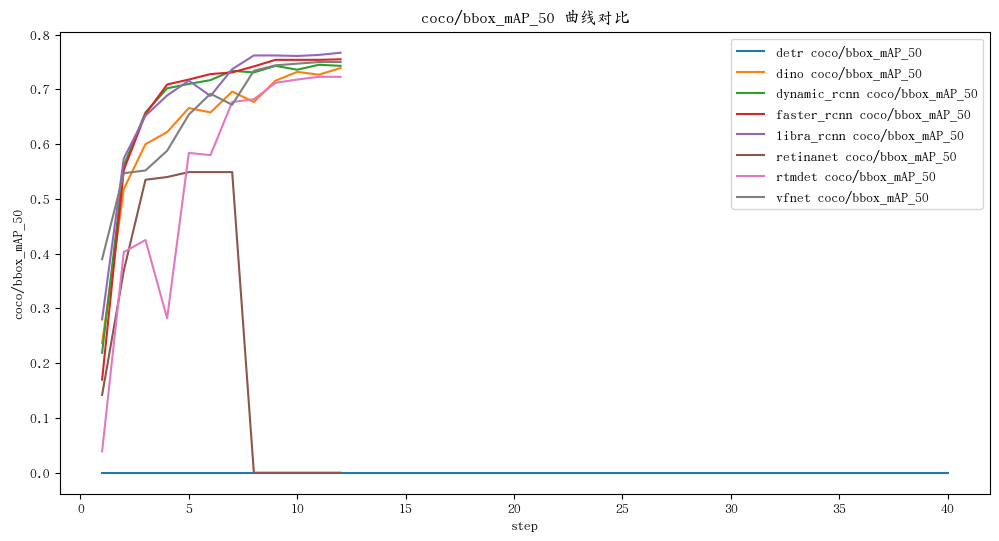

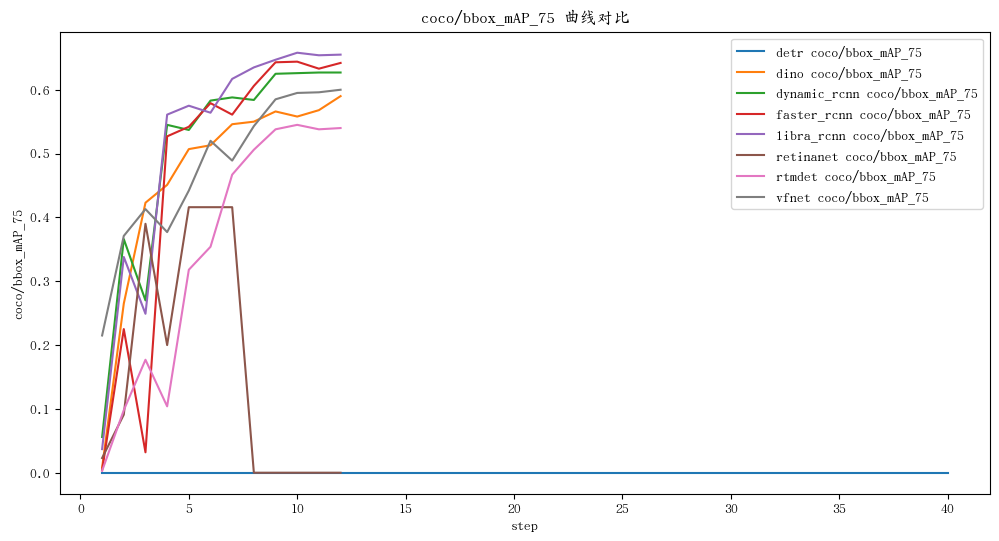

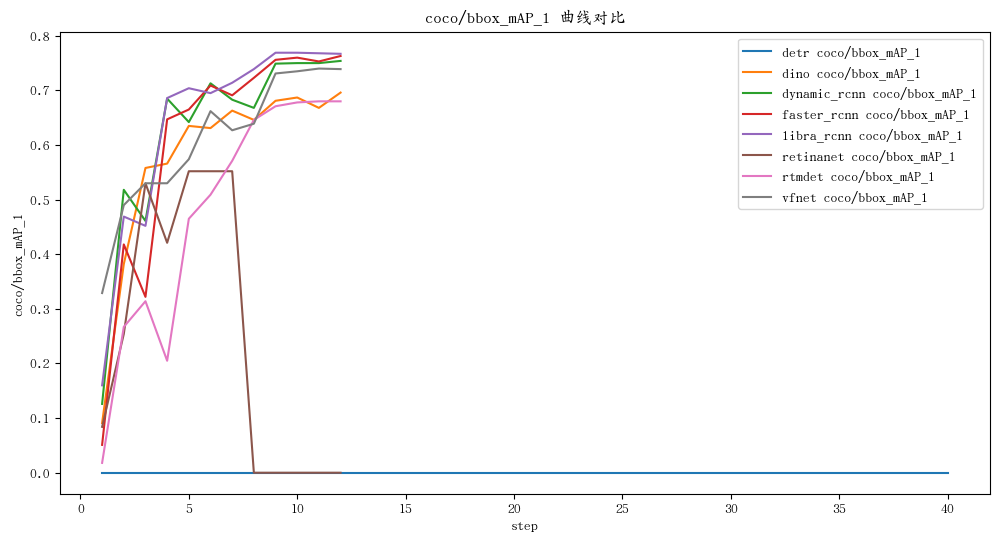

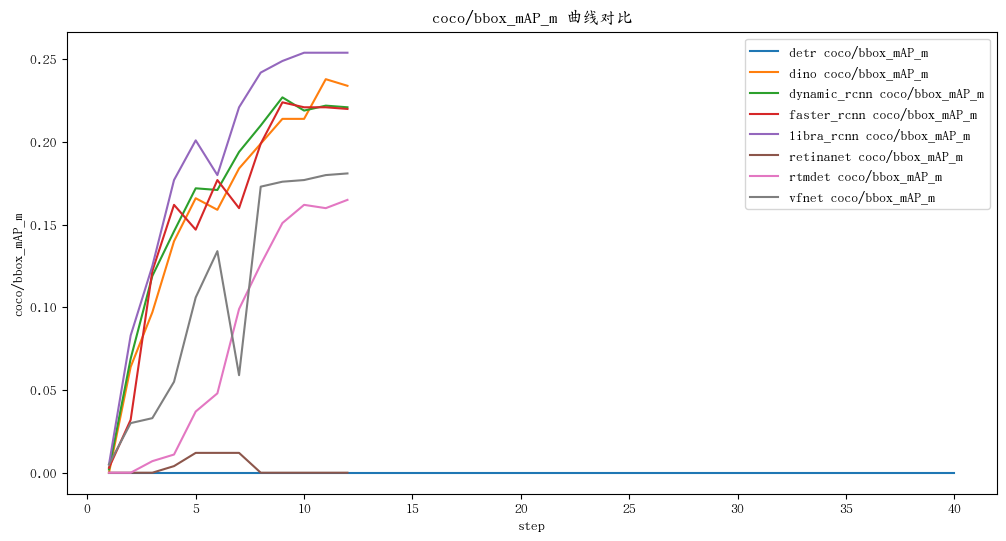

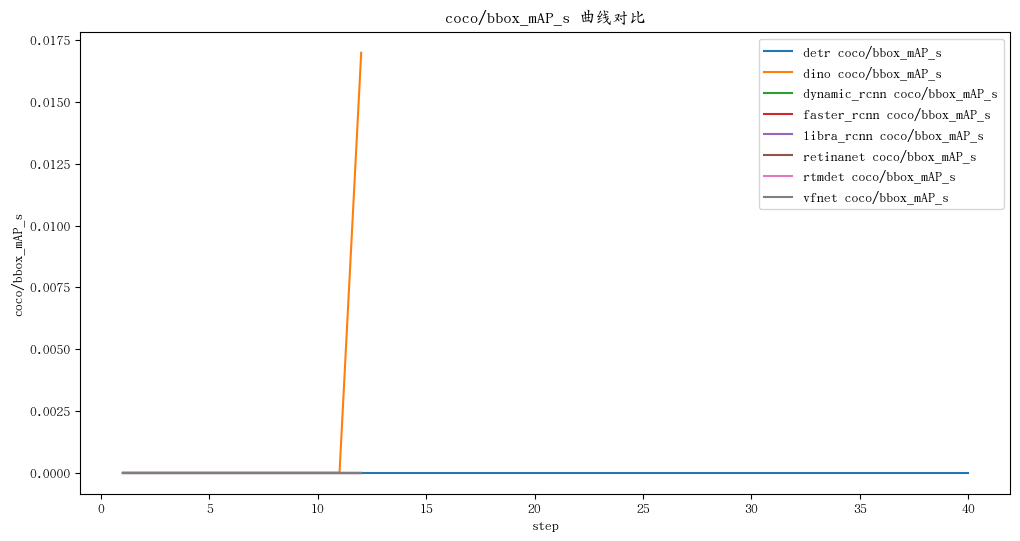

In [6]:
# mAP相关曲线分组对比
map_keys = ['coco/bbox_mAP_50', 'coco/bbox_mAP_75', 'coco/bbox_mAP_l', 'coco/bbox_mAP_m', 'coco/bbox_mAP_s']
for k in map_keys:
    if k in df.columns:
        plt.figure(figsize=(12, 6))
        for group, dfg in df.groupby('group'):
            plt.plot(dfg['step'], dfg[k], label=f'{group} {k}')
        plt.xlabel('step')
        plt.ylabel(k)
        plt.title(f'{k} 曲线对比')
        plt.legend()
        plt.show()

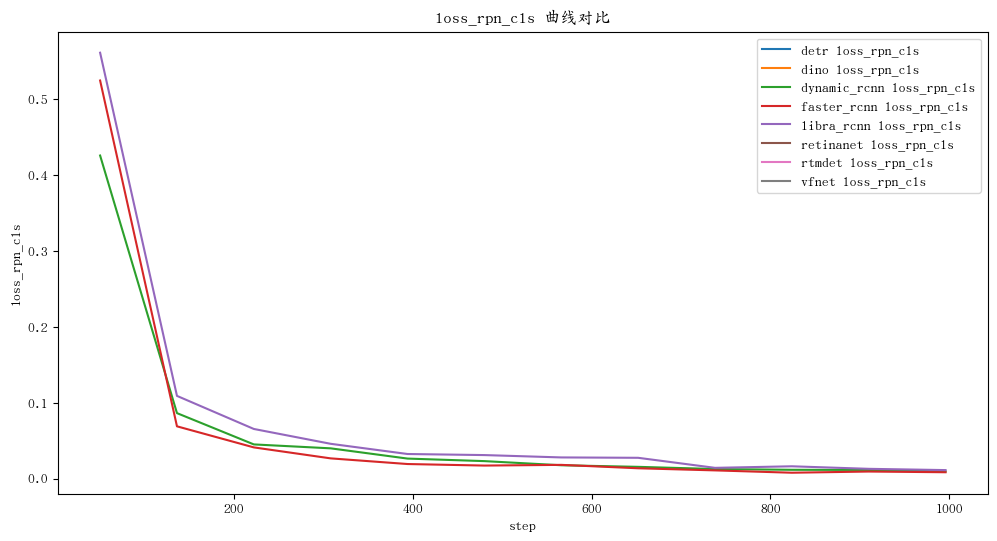

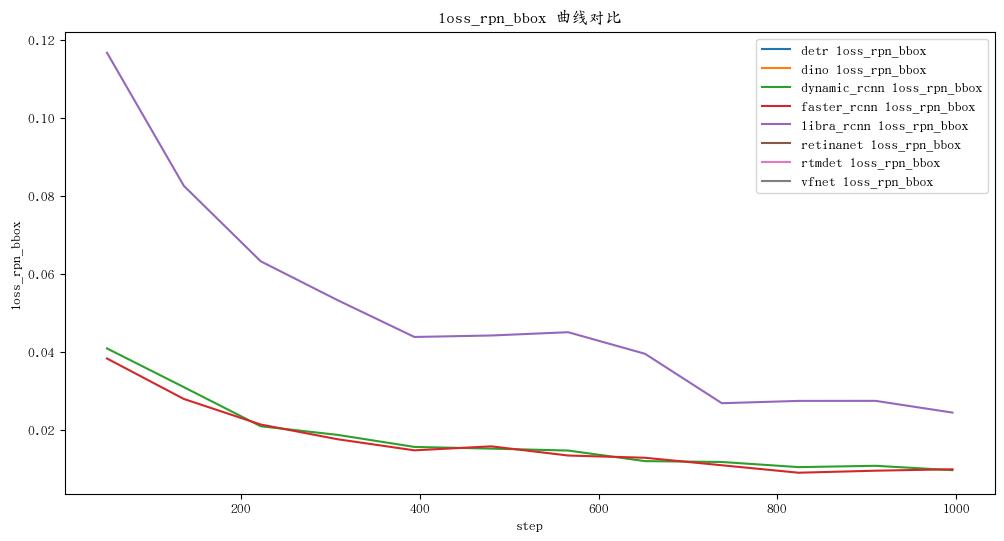

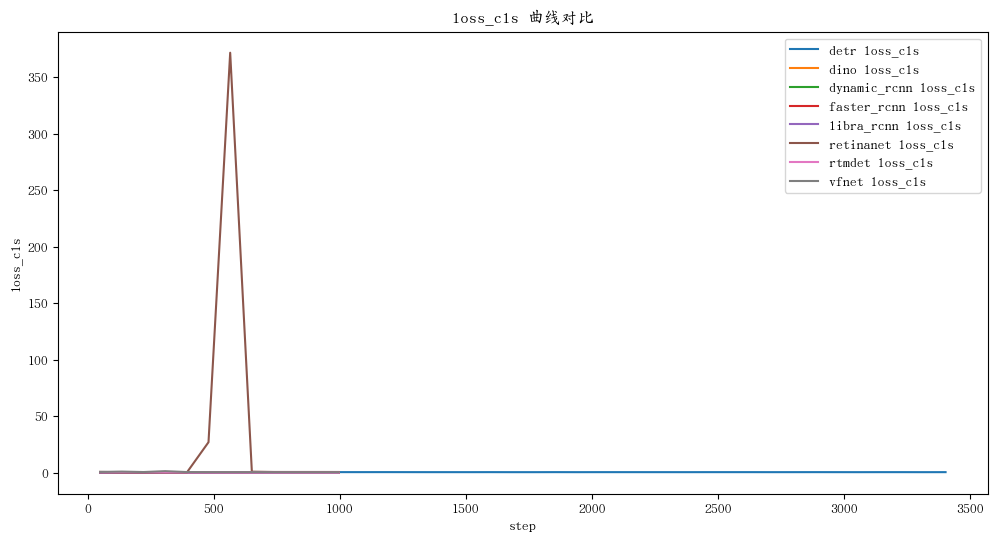

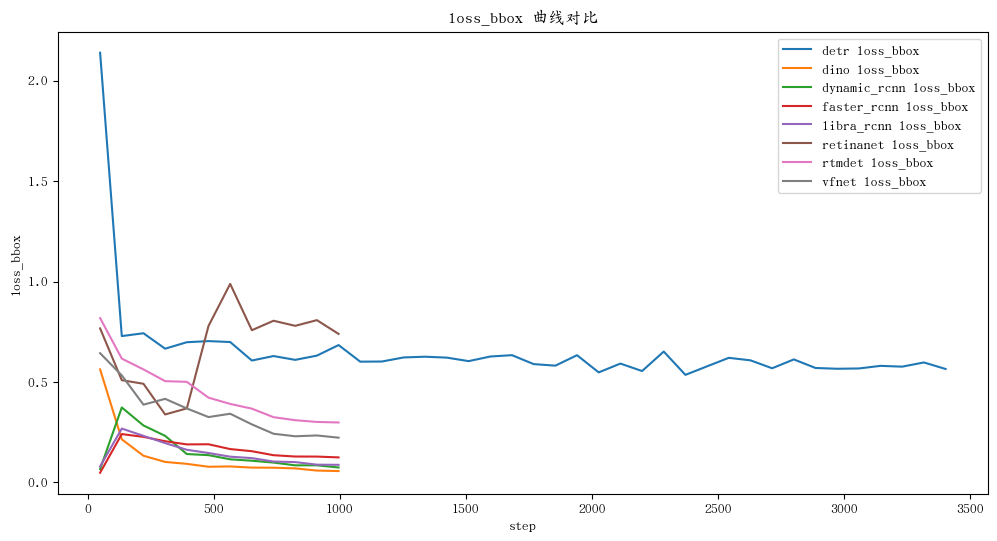

In [7]:
# loss分量分组对比
loss_keys = ['loss_rpn_cls', 'loss_rpn_bbox', 'loss_cls', 'loss_bbox']
for k in loss_keys:
    if k in df.columns:
        plt.figure(figsize=(12, 6))
        for group, dfg in df.groupby('group'):
            plt.plot(dfg['step'], dfg[k], label=f'{group} {k}')
        plt.xlabel('step')
        plt.ylabel(k)
        plt.title(f'{k} 曲线对比')
        plt.legend()
        plt.show()

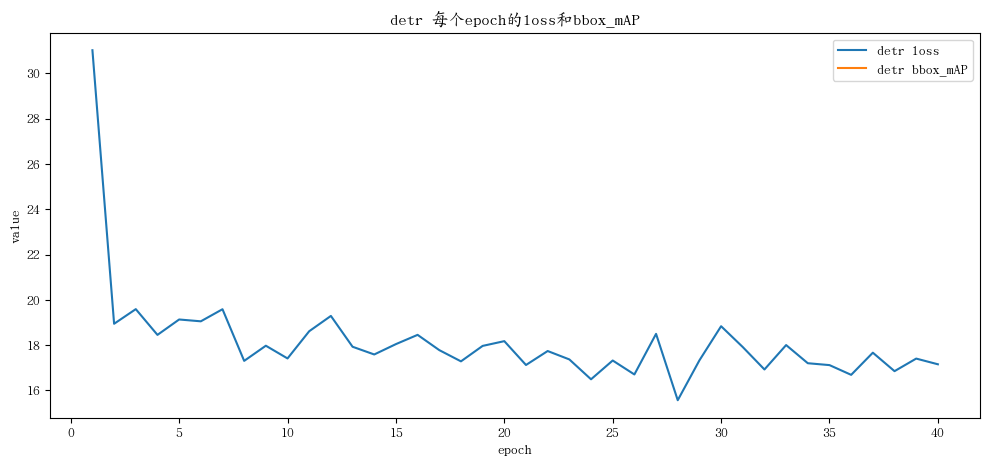

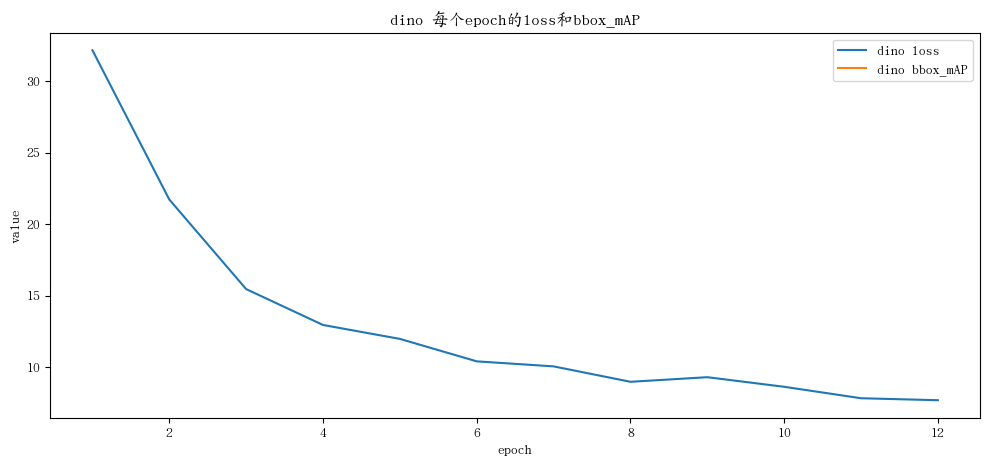

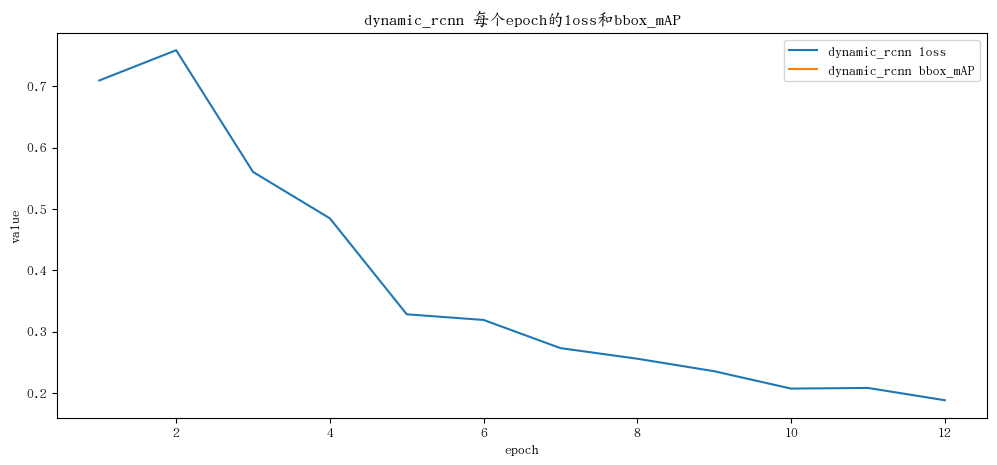

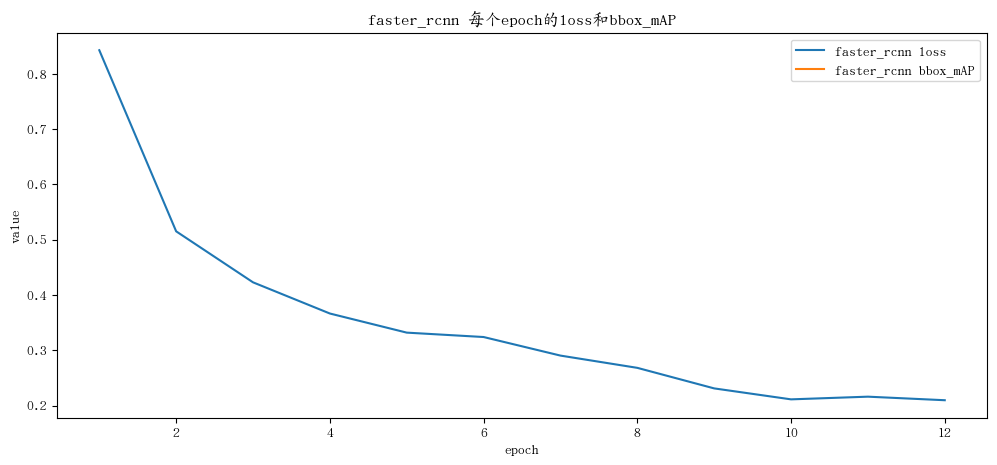

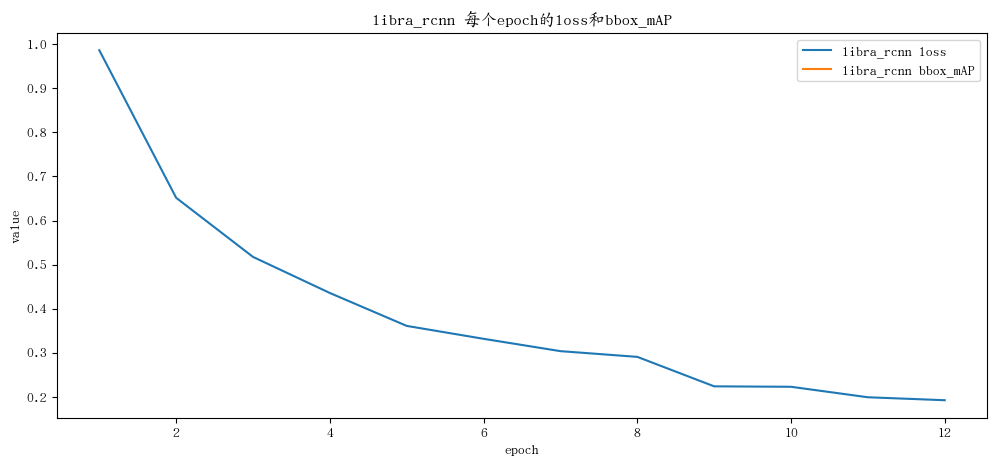

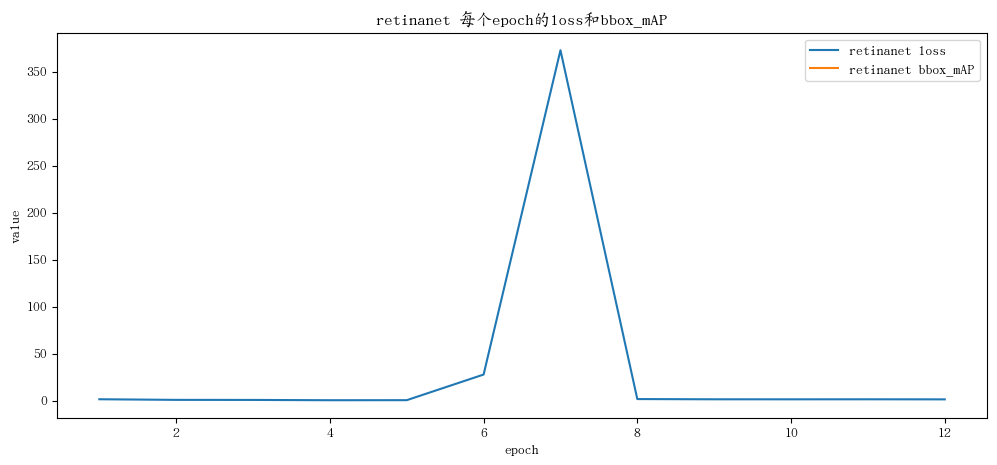

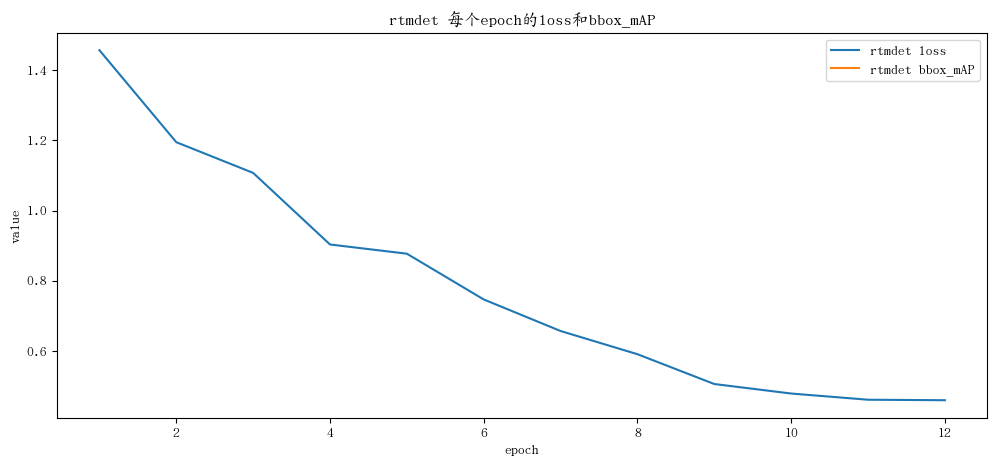

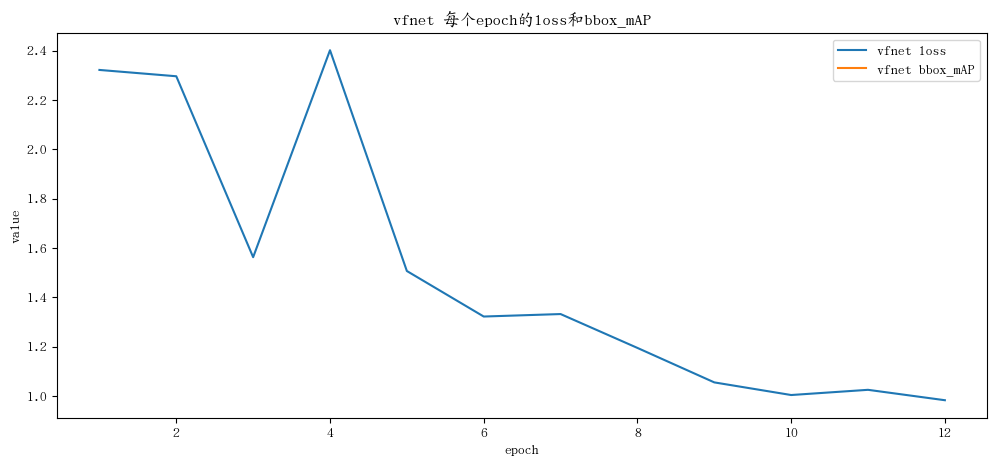

In [8]:
# 按epoch分组对比loss和mAP等指标（每个epoch最后一个step）
if 'epoch' in df.columns:
    for group, dfg in df.groupby('group'):
        df_epoch = dfg.sort_values('step').groupby('epoch').tail(1)
        plt.figure(figsize=(12, 5))
        plt.plot(df_epoch['epoch'], df_epoch['loss'], label=f'{group} loss')
        if 'coco/bbox_mAP' in df_epoch.columns:
            plt.plot(df_epoch['epoch'], df_epoch['coco/bbox_mAP'], label=f'{group} bbox_mAP')
        plt.xlabel('epoch')
        plt.ylabel('value')
        plt.title(f'{group} 每个epoch的loss和bbox_mAP')
        plt.legend()
        plt.show()

In [9]:
# 分组统计主要指标的最大/最小/平均值
metrics = ['loss', 'acc', "coco/bbox_mAP", "coco/bbox_mAP_50", "coco/bbox_mAP_75", "coco/bbox_mAP_s", "coco/bbox_mAP_m", "coco/bbox_mAP_l"]
for group, dfg in df.groupby('group'):
    print(f'==== {group} ====')
    for m in metrics:
        if m in dfg.columns:
            print(f'{m}: max={dfg[m].max():.4f}, min={dfg[m].min():.4f}, mean={dfg[m].mean():.4f}')

==== detr ====
loss: max=31.0261, min=15.5680, mean=18.1385
acc: max=nan, min=nan, mean=nan
coco/bbox_mAP: max=0.0000, min=0.0000, mean=0.0000
coco/bbox_mAP_50: max=0.0000, min=0.0000, mean=0.0000
coco/bbox_mAP_75: max=0.0000, min=0.0000, mean=0.0000
coco/bbox_mAP_s: max=0.0000, min=0.0000, mean=0.0000
coco/bbox_mAP_m: max=0.0000, min=0.0000, mean=0.0000
coco/bbox_mAP_l: max=0.0000, min=0.0000, mean=0.0000
==== dino ====
loss: max=32.1442, min=7.7018, mean=13.1024
acc: max=nan, min=nan, mean=nan
coco/bbox_mAP: max=0.5300, min=0.0600, mean=0.4248
coco/bbox_mAP_50: max=0.7390, min=0.2370, mean=0.6323
coco/bbox_mAP_75: max=0.5900, min=0.0080, mean=0.4621
coco/bbox_mAP_s: max=0.0170, min=0.0000, mean=0.0014
coco/bbox_mAP_m: max=0.2380, min=0.0000, mean=0.1591
coco/bbox_mAP_l: max=0.6960, min=0.0910, mean=0.5753
==== dynamic_rcnn ====
loss: max=0.7586, min=0.1882, mean=0.3773
acc: max=96.6309, min=89.5752, mean=93.5710
coco/bbox_mAP: max=0.5590, min=0.0830, mean=0.4535
coco/bbox_mAP_50: max

In [10]:
# 生成分组统计表格并保存到root_dir/summary.txt
import numpy as np
from tabulate import tabulate

metrics = ['loss', 'acc', "coco/bbox_mAP", "coco/bbox_mAP_50", "coco/bbox_mAP_75", "coco/bbox_mAP_s", "coco/bbox_mAP_m", "coco/bbox_mAP_l"]
rows = []
for group, dfg in df.groupby('group'):
    row = [group]
    for m in metrics:
        if m in dfg.columns:
            vals = dfg[m].replace([np.inf, -np.inf], np.nan)
            row.extend([f'{vals.max():.4f}', f'{vals.min():.4f}', f'{vals.mean():.4f}'])
        else:
            row.extend(['', '', ''])
    rows.append(row)
header = ['group'] + sum([[f'{m}_max', f'{m}_min', f'{m}_mean'] for m in metrics], [])
table_str = tabulate(rows, headers=header, tablefmt='grid')
print(table_str)
with open(os.path.join(root_dir, 'summary.txt'), 'w') as f:
    f.write(table_str)

+--------------+------------+------------+-------------+-----------+-----------+------------+---------------------+---------------------+----------------------+------------------------+------------------------+-------------------------+------------------------+------------------------+-------------------------+-----------------------+-----------------------+------------------------+-----------------------+-----------------------+------------------------+-----------------------+-----------------------+------------------------+
| group        |   loss_max |   loss_min |   loss_mean |   acc_max |   acc_min |   acc_mean |   coco/bbox_mAP_max |   coco/bbox_mAP_min |   coco/bbox_mAP_mean |   coco/bbox_mAP_50_max |   coco/bbox_mAP_50_min |   coco/bbox_mAP_50_mean |   coco/bbox_mAP_75_max |   coco/bbox_mAP_75_min |   coco/bbox_mAP_75_mean |   coco/bbox_mAP_s_max |   coco/bbox_mAP_s_min |   coco/bbox_mAP_s_mean |   coco/bbox_mAP_m_max |   coco/bbox_mAP_m_min |   coco/bbox_mAP_m_mean |   coco/bb